In [ ]:
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

# Optional: Suppress convergence warnings for cleaner output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load dataset
df = pd.read_excel("/content/cleaned_data_academic_performance.xlsx")

# Encode string/object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

# Features and target
x = df.drop(columns=['PERCENTILE']).values
y = pd.qcut(df['PERCENTILE'], q=4, labels=False)

# Scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.25, random_state=23
)

# Base estimators with specified hyperparameters
tree = DecisionTreeClassifier(
    max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=23
)

logistic = LogisticRegression(
    C=0.5, solver="lbfgs", max_iter=2000, random_state=23
)

svm = SVC(
    C=1.0, gamma=0.5, kernel='rbf', probability=True, random_state=23
)

# Bagging - Decision Tree
bagging_tree = BaggingClassifier(estimator=tree, n_estimators=5, max_samples=50, bootstrap=True)
bagging_tree.fit(x_train, y_train)
print("--- Decision Tree Bagging ---")
print(f"Train score: {bagging_tree.score(x_train, y_train)}")
print(f"Test score: {bagging_tree.score(x_test, y_test)}")

# Bagging - Logistic Regression
bagging_logistic = BaggingClassifier(estimator=logistic, n_estimators=5, max_samples=50, bootstrap=True)
bagging_logistic.fit(x_train, y_train)
print("\n--- Logistic Regression Bagging ---")
print(f"Train score: {bagging_logistic.score(x_train, y_train)}")
print(f"Test score: {bagging_logistic.score(x_test, y_test)}")

# Bagging - SVM
bagging_svm = BaggingClassifier(estimator=svm, n_estimators=5, max_samples=50, bootstrap=True)
bagging_svm.fit(x_train, y_train)
print("\n--- SVM Bagging ---")
print(f"Train score: {bagging_svm.score(x_train, y_train)}")
print(f"Test score: {bagging_svm.score(x_test, y_test)}")

# Individual models for comparison
print("\n--- Individual Models (without Bagging) ---")
tree.fit(x_train, y_train)
logistic.fit(x_train, y_train)
svm.fit(x_train, y_train)
print(f"Decision Tree - Test score: {tree.score(x_test, y_test)}")
print(f"Logistic Regression - Test score: {logistic.score(x_test, y_test)}")
print(f"SVM - Test score: {svm.score(x_test, y_test)}")


--- Decision Tree Bagging ---
Train score: 0.9764541173475881
Test score: 0.9732722413134784

--- Logistic Regression Bagging ---
Train score: 0.7849051800941835
Test score: 0.7854142802596411

--- SVM Bagging ---
Train score: 0.23482245131729668
Test score: 0.235586101565483

--- Individual Models (without Bagging) ---
Decision Tree - Test score: 0.9904543718976708
Logistic Regression - Test score: 0.9587628865979382
SVM - Test score: 0.26918671248568155


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_conf_matrix(model, x_test, y_test, title):
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()


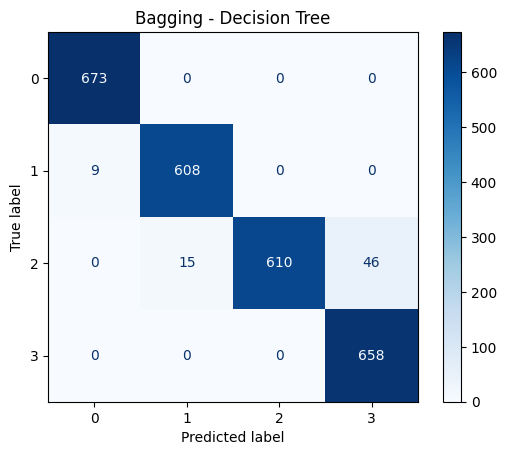

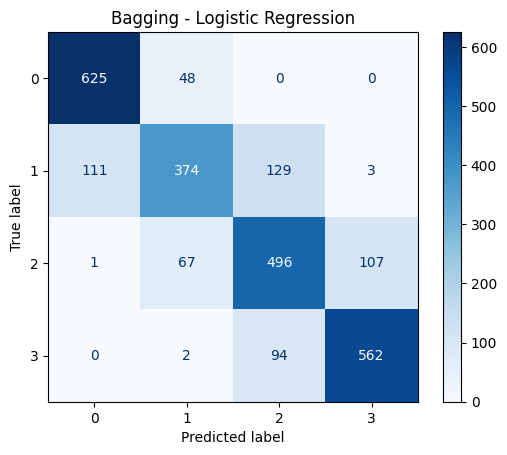

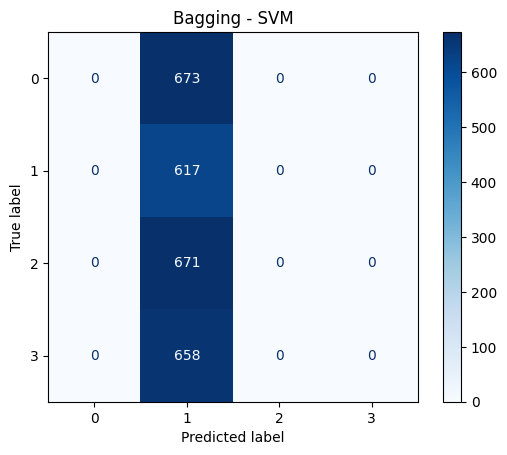

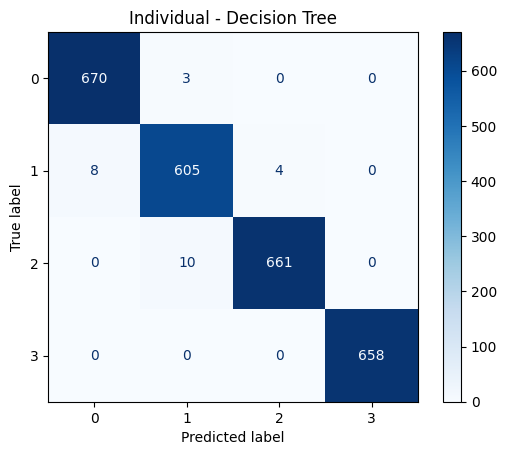

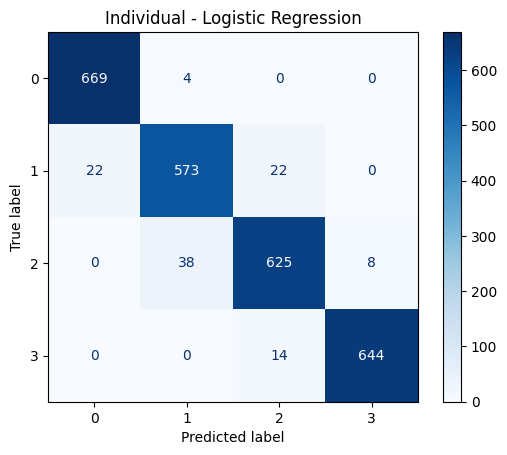

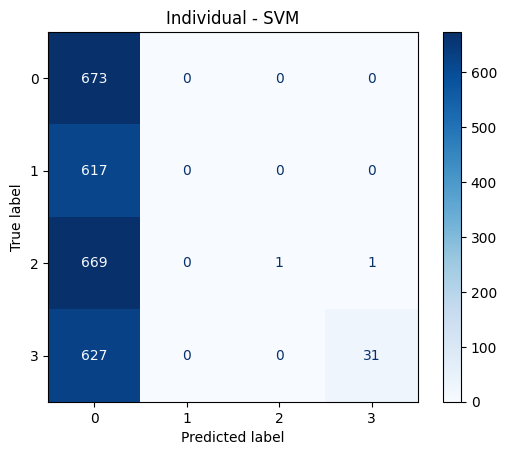

In [ ]:
# --- CONFUSION MATRICES ---

# Bagging Models
plot_conf_matrix(bagging_tree, x_test, y_test, "Bagging - Decision Tree")
plot_conf_matrix(bagging_logistic, x_test, y_test, "Bagging - Logistic Regression")
plot_conf_matrix(bagging_svm, x_test, y_test, "Bagging - SVM")

# Individual Models
plot_conf_matrix(tree, x_test, y_test, "Individual - Decision Tree")
plot_conf_matrix(logistic, x_test, y_test, "Individual - Logistic Regression")
plot_conf_matrix(svm, x_test, y_test, "Individual - SVM")


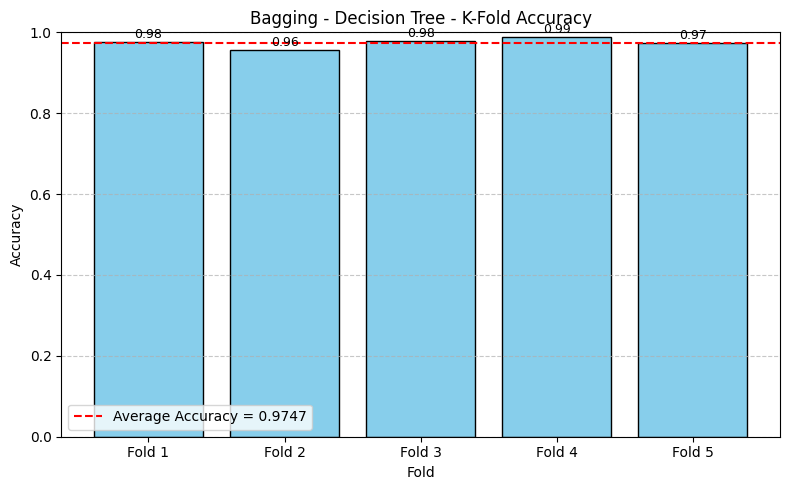

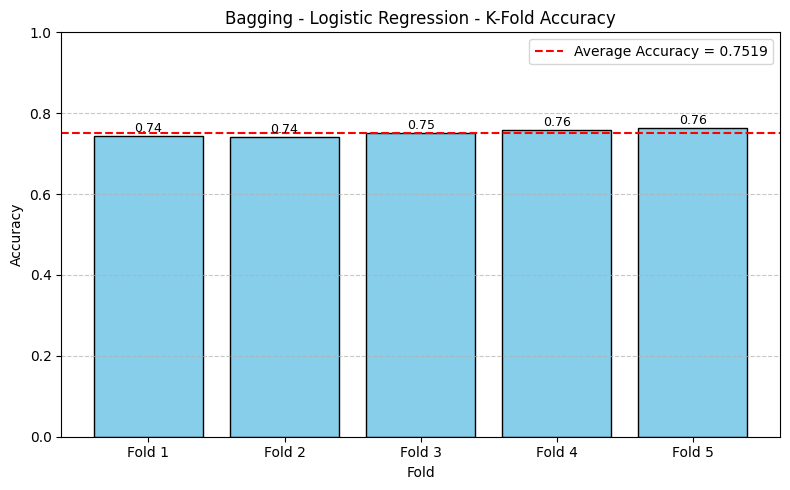

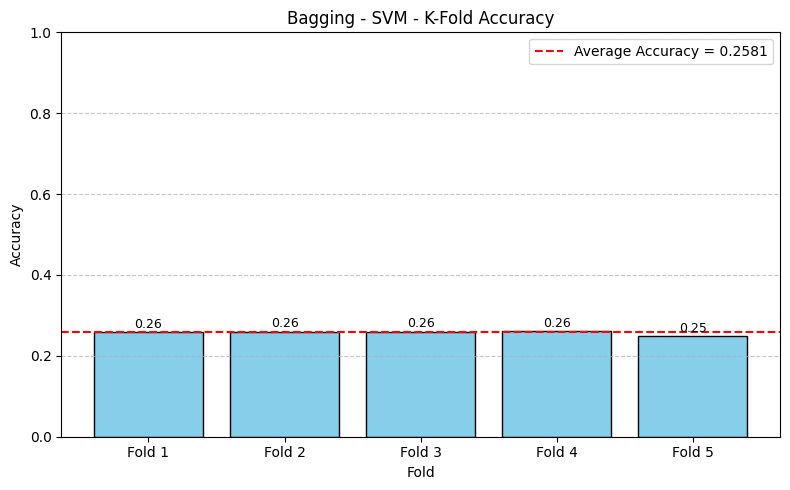

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_excel("/content/cleaned_data_academic_performance.xlsx")

# Encode string/object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

# Features and target
x = df.drop(columns=['PERCENTILE']).values
y = pd.qcut(df['PERCENTILE'], q=4, labels=False)

# Scale features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Define K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)

# Define base models with hyperparameters
tree = DecisionTreeClassifier(max_depth=6, min_samples_split=10, min_samples_leaf=5, random_state=23)
logistic = LogisticRegression(C=0.1, solver="lbfgs", max_iter=2000, random_state=23)
svm = SVC(C=1.0, gamma=0.5, kernel='rbf', probability=True, random_state=23)

# Define Bagging models
models = {
    "Bagging - Decision Tree": BaggingClassifier(estimator=tree, n_estimators=5, max_samples=50, bootstrap=True),
    "Bagging - Logistic Regression": BaggingClassifier(estimator=logistic, n_estimators=5, max_samples=50, bootstrap=True),
    "Bagging - SVM": BaggingClassifier(estimator=svm, n_estimators=5, max_samples=50, bootstrap=True),
}

# Perform K-Fold and plot results
for name, model in models.items():
    fold_accuracies = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(x_scaled, y), 1):
        x_train, x_test = x_scaled[train_idx], x_scaled[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        acc = accuracy_score(y_test, y_pred)
        fold_accuracies.append(acc)

    # Plot accuracy per fold
    plt.figure(figsize=(8, 5))
    bars = plt.bar(range(1, 6), fold_accuracies, color='skyblue', edgecolor='black')
    plt.axhline(np.mean(fold_accuracies), color='red', linestyle='--', label=f'Average Accuracy = {np.mean(fold_accuracies):.4f}')
    plt.xticks(range(1, 6), [f"Fold {i}" for i in range(1, 6)])
    plt.ylim(0, 1)
    plt.title(f"{name} - K-Fold Accuracy")
    plt.xlabel("Fold")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Label each bar with its accuracy
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()
